# Turbulence

In [1]:
import numpy as np
import time as tmod

# Athena++ modules
import athena_read
import matplotlib.pyplot as plt

## Load turbulence data

In [2]:
# Specify the data read in parameters for the high and low turbulent states
SNAP = 1
qshear = 1.5
STRAT = 1

DIRECTORY='/mnt/lustre/user/cfairbairn/InclinedPert/turb_agn/'
EXPID = 'turb'

DATA_FILE = DIRECTORY+'{0}.out1.{1:05d}.athdf'.format(EXPID,SNAP)

QUANTITIES = ['rho','vel1','vel2','vel3']
LEVEL = None  # Sets the refinement level onto which the data is cast (0 being the coursest root refinement).

In [3]:
# Read in the high turbulence state
data = athena_read.athdf(DATA_FILE, quantities=QUANTITIES,level=LEVEL)

# Cell centers
xc = data['x1v']
yc = data['x2v']
zc = data['x3v']

# Extract the number of cells
nx = len(xc)
ny = len(yc)
nz = len(zc)

# Load in the density and momentum
dens = data['rho'].T
velx = data['vel1'].T
vely = data['vel2'].T
velz = data['vel3'].T

px = dens*velx
py = dens*vely
pz = dens*velz

print('nx = ', nx)
print('ny = ', ny)
print('nz = ', nz)

# Dimensions of data array
print(np.shape(xc))
print('xc left = ', xc[0], ' xc right = ', xc[-1])
Lx = data['x1f'][-1] - data['x1f'][0]
print('Lx = ', Lx)

print('Time = ', data['Time'])

print('Minimum dens = ',np.min(dens))
print('Maximum dens = ',np.max(dens))

nx =  128
ny =  128
nz =  128
(128,)
xc left =  -0.009921875  xc right =  0.009921875
Lx =  0.02
Time =  0.3146091
Minimum dens =  0.00036937464
Maximum dens =  1.0249645


In [4]:
xcmesh,ycmesh,zcmesh = np.meshgrid(xc,yc,zc,indexing='ij')

dens0  = np.exp(-STRAT*zcmesh**2/2)

dens_pert = (dens - dens0)

dvely = vely + qshear*xcmesh

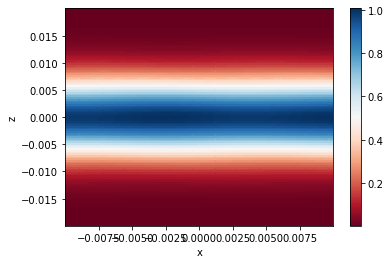

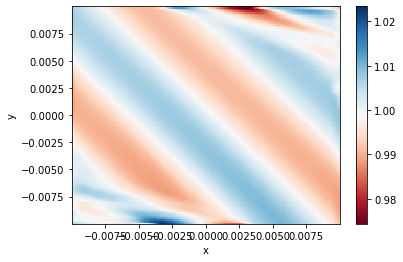

In [5]:
quantity = dens

YAVG = False

# Define a slice variable
slice_index = int(ny/2)
slice = np.s_[:,slice_index,:]

if YAVG:
    plt.pcolormesh(xcmesh[slice],zcmesh[slice],np.mean(quantity,axis=1),cmap='RdBu',shading='nearest')
else:
    plt.pcolormesh(xcmesh[slice],zcmesh[slice],quantity[slice],cmap='RdBu',shading='nearest')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('z')

plt.show()

# Define a slice variable
slice_index = int(nz/2)
slice = np.s_[:,:,slice_index]

plt.pcolormesh(xcmesh[slice],ycmesh[slice],quantity[slice],cmap='RdBu',shading='nearest')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')

plt.show()

/home/cfairbairn/Installs/miniconda3/envs/athena/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in power
/home/cfairbairn/Installs/miniconda3/envs/athena/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in power


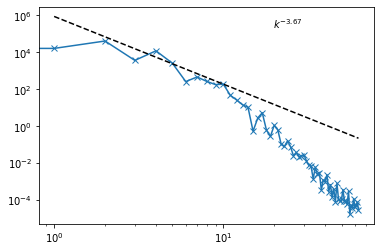

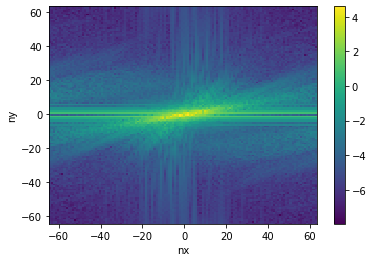

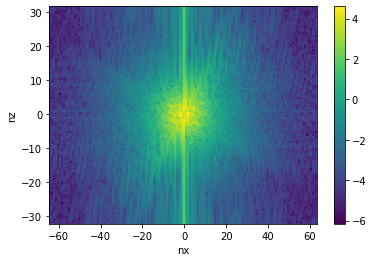

In [127]:
# Set up a test sinusoidal velocity field

ft_vx = np.fft.fftn(velx)
ft_vy = np.fft.fftn(vely+qshear*xcmesh)
ft_vz = np.fft.fftn(velz)

ft_kx = np.fft.fftfreq(nx,d=(xc[1]-xc[0]))*2*np.pi
ft_ky = np.fft.fftfreq(ny,d=(yc[1]-yc[0]))*2*np.pi
ft_kz = np.fft.fftfreq(nz,d=(zc[1]-zc[0]))*2*np.pi

# Order the frequencies and fourier transforms
ft_vx = np.fft.fftshift(ft_vx)
ft_vy = np.fft.fftshift(ft_vy)
ft_vz = np.fft.fftshift(ft_vz)
ft_kx = np.fft.fftshift(ft_kx)
ft_ky = np.fft.fftshift(ft_ky)
ft_kz = np.fft.fftshift(ft_kz)

nkx = len(ft_kx)
nky = len(ft_ky)
nkz = len(ft_kz)

xaxis = np.s_[:,int(nky/2),int(nkz/2)]
yaxis = np.s_[int(nkx/2),:,int(nkz/2)]
zaxis = np.s_[int(nkx/2),int(nky/2),:]

xyplane = np.s_[:, :, int(nkz/2)]
xzplane = np.s_[:, int(nky/2), :]
yzplane = np.s_[int(nkx/2), :, :]

axslice = xaxis
slope=-11/3

RANGE_SWITCH = 1

power_spectrum = (np.abs(ft_vx)**2 + np.abs(ft_vy)**2 + np.abs(ft_vz)**2)/2

# Plot slices through the full Fourier spectrum
plt.loglog(ft_kx*Lx/(2*np.pi),power_spectrum[axslice],marker='x')
# Plot a Kolmogorov -5/3 slope for comparison
plt.loglog(ft_kx*Lx/(2*np.pi),power_spectrum[axslice][int(nx/2)+10]*pow(ft_kx/ft_kx[int(nx/2)+10],slope),linestyle='--',color='black')
# Print out the slope
plt.text(0.7,0.9,r'$k^{%1.2f}$' % slope,transform=plt.gca().transAxes)
plt.show()

if RANGE_SWITCH:
    plt.pcolormesh(ft_kx*Lx/(2*np.pi),ft_ky*Lx/(2*np.pi),np.log10(power_spectrum[xyplane].T),shading='nearest')
    plt.xlabel('nx')
    plt.ylabel('ny')
    plt.colorbar()
    plt.show()

    plt.pcolormesh(ft_kx*Lx/(2*np.pi),ft_kz*Lx/(2*np.pi),np.log10(power_spectrum[xzplane].T),shading='nearest')
    plt.xlabel('nx')
    plt.ylabel('nz')
    plt.colorbar()
    plt.show()

else:
    plt.pcolormesh(ft_kx,ft_ky,np.log10(power_spectrum[xyplane].T),shading='nearest')
    plt.xlabel('kx')
    plt.ylabel('ky')
    plt.xlim(-30*np.pi,30*np.pi)
    plt.ylim(-30*np.pi,30*np.pi)
    plt.colorbar()
    plt.show()

    plt.pcolormesh(ft_kx,ft_kz,np.log10(power_spectrum[xzplane].T),shading='nearest')
    plt.xlabel('kx')
    plt.ylabel('kz')
    plt.xlim(-30*np.pi,30*np.pi)
    plt.ylim(-30*np.pi,30*np.pi)
    plt.colorbar()
    plt.show()


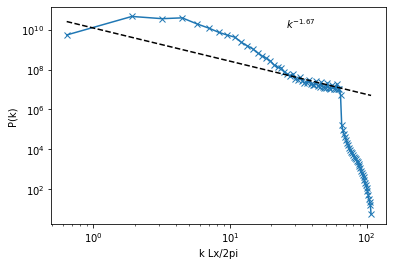

In [165]:
# Now integrate over shells in k-space to get a 1D power spectrum

kmax = np.sqrt(np.max(ft_kx)**2 + np.max(ft_ky)**2 + np.max(ft_kz)**2)
nk = int(np.sqrt(nx**2 + ny**2 + nz**2)/2)
dk = 2 #kmax/nk
nk = int(kmax/dk)
kvals = (np.arange(nk)+0.5)*dk
powerspec_1D = np.zeros(nk)

for i in range(nkx):
    for j in range(nky):
        for k in range(nkz):
            k_mag = np.sqrt(ft_kx[i]**2 + ft_ky[j]**2 + ft_kz[k]**2)
            k_index = int(k_mag/dk)
            if k_index < nk:
                powerspec_1D[k_index] += power_spectrum[i,j,k]
                # powerspec_1D[k_index] += 1

slope = -5/3

plt.loglog(kvals*Lx/(2*np.pi),powerspec_1D,marker='x')
# Plot a Kolmogorov -5/3 slope for comparison
plt.loglog(kvals*Lx/(2*np.pi),powerspec_1D[int(nk/4)]*pow(kvals/kvals[int(nk/4)],slope),linestyle='--',color='black')
# Print out the slope
plt.text(0.7,0.9,r'$k^{%1.2f}$' % slope,transform=plt.gca().transAxes)
plt.xlabel(r'k Lx/2pi')
plt.ylabel(r'P(k)')
plt.show()

Compute power spectra for velocity perturbations

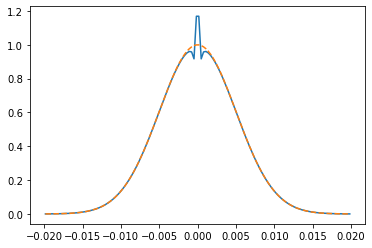

In [89]:
# Plot a cut through the center of the domain

plt.plot(zc,np.average(dens,axis=(0,1)),label='Density')

# Overplot the analytical expectation
plt.plot(zc,np.exp(-zc**2/(2*0.005*0.005)),ls='--')

Compute distributions for velocity and density perturbations

In [167]:
# Define the bin edges
BIN_LEFT= -3.e-1
# BIN_LEFT= 0.0
BIN_RIGHT= 3.e-1
NBINS = 100
PDF = True
bin_edges = np.linspace(BIN_LEFT,BIN_RIGHT,NBINS)

# Now compute the histogram of the residuals
hist_dvx = np.histogram(velx,bins=bin_edges,weights=(dens),density=PDF)
hist_dvy = np.histogram(vely+qshear*xcmesh,bins=bin_edges,weights=(dens),density=PDF)
hist_dvz = np.histogram(velz,bins=bin_edges,weights=(dens),density=PDF)

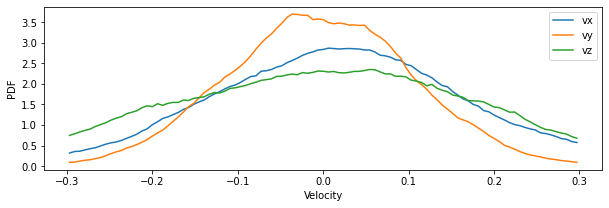

In [168]:
# Plot the histograms
fig = plt.figure(figsize=(10, 3), constrained_layout=False)
grid = fig.add_gridspec(ncols=1, nrows=1, width_ratios = [1], height_ratios = [1.0])
bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])
plt.plot(bin_centers,hist_dvx[0],label='vx')
plt.plot(bin_centers,hist_dvy[0],label='vy')
plt.plot(bin_centers,hist_dvz[0],label='vz')
plt.xlabel('Velocity')
plt.ylabel('PDF')
plt.legend()
plt.show()

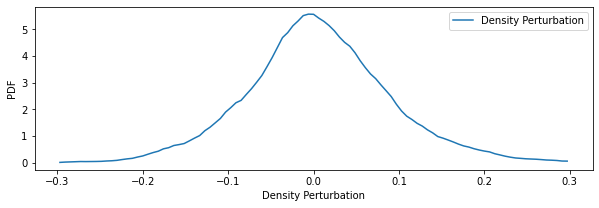

In [169]:
dens_pert = dens - dens0

# Now do the same for the density perturbation
BIN_LEFT= -0.3
BIN_RIGHT= 0.3
NBINS = 100
PDF = True
bin_edges = np.linspace(BIN_LEFT,BIN_RIGHT,NBINS)
# Now compute the histogram of the residuals
hist_dens = np.histogram(dens_pert,bins=bin_edges,weights=(dens),density=PDF)
# Plot the histograms
fig = plt.figure(figsize=(10, 3), constrained_layout=False)
grid = fig.add_gridspec(ncols=1, nrows=1, width_ratios = [1], height_ratios = [1.0])
bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])
plt.plot(bin_centers,hist_dens[0],label='Density Perturbation')
plt.xlabel('Density Perturbation')
plt.ylabel('PDF')
plt.legend()
plt.show()

## Read in the history file

In [54]:
hist = np.loadtxt('/mnt/lustre/user/cfairbairn/InclinedPert/turbtest/turb.hst')

t_hst = hist[:,0]
dt_hst = hist[:,1]
mass_hst = hist[:,2]
mom1_hst = hist[:,3]
mom2_hst = hist[:,4]
mom3_hst = hist[:,5]
ekinx_hst = hist[:,6]
ekiny_hst = hist[:,7]
ekinz_hst = hist[:,8]
dvxdvy_hst = hist[:,9]

print(t_hst[-1]/np.pi)

T = 2*np.pi

1.0534211035343606


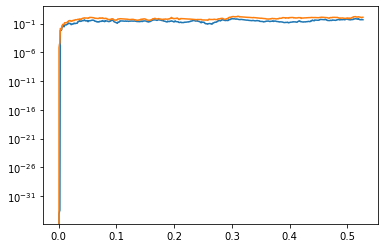

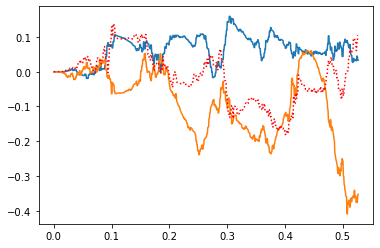

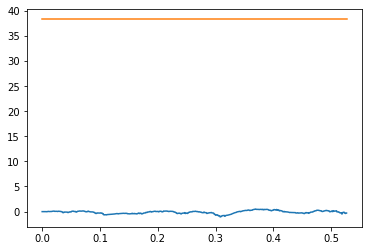

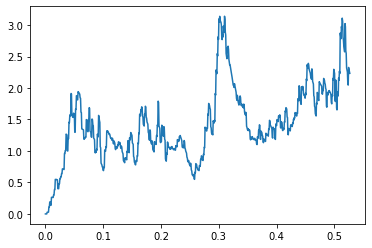

In [55]:
plt.plot(t_hst/T,ekinx_hst)
# plt.plot(t_hst/T,ekiny_hst)
plt.plot(t_hst/T,ekinz_hst)
plt.yscale('log')
plt.show()

plt.plot(t_hst/T,mom1_hst)
plt.plot(t_hst/T,mom2_hst)
plt.plot(t_hst/T,mom3_hst,color='r',ls=':')
plt.show()

plt.plot(t_hst/T,dvxdvy_hst)
plt.plot(t_hst/T,mass_hst)
plt.show()

plt.plot(t_hst/T,ekinx_hst+ekinx_hst+ekinz_hst)
plt.show()

## Compare to MRI shearing box tests

In [58]:
def ReadData(SNAP,DIMS=3,EXP='',FILE_PREFIX='HGB.mhd_w_bcc',HIST_PREFIX='HGB.user',PROJECT_DIR='/mnt/lustre/user/cfairbairn/Sloshing_MRI/'):

    # -------------------------------------- #
    # READ IN THE DATA 
    # -------------------------------------- #

    DATA_FILE = PROJECT_DIR+'{0}bin/{1}.{2:05d}.athdf'.format(EXP,FILE_PREFIX,SNAP)
    HIST_FILE = PROJECT_DIR+'{0}{1}.hst'.format(EXP,HIST_PREFIX)

    QUANTITIES = mhd_w_bcc
    LEVEL = 0  # Sets the refinement level onto which the data is cast (0 being the coursest root refinement).

    if QUANTITIES[0] == 'Levels':
        data = athena_read.athdf(DATA_FILE, quantities=QUANTITIES[1:],
                                level=LEVEL, return_levels=True)
    else:
        data = athena_read.athdf(DATA_FILE, quantities=QUANTITIES,
                                level=LEVEL)

    # Extract the time
    t = data['Time']

    # ------------------------------------------- #
    if DIMS == 3:
    # ------------------------------------------- #

        # Cell centers
        xc = data['x1v']
        yc = data['x2v']
        zc = data['x3v']

        # Cell faces
        xf = data['x1f']
        yf = data['x2f']
        zf = data['x3f']

         # If len of yc > 1 then throw an error
        if len(zc) == 1:
            raise ValueError("Careful, x3 dimension is length 1 -- is this a 2D sim?")

        # Load in the density and momentum
        dens = data['dens'].T
        velx = data['velx'].T
        vely = data['vely'].T
        velz = data['velz'].T

        # Load in the cell centered magnetic field
        Bx = data['bcc1'].T
        By = data['bcc2'].T
        Bz = data['bcc3'].T

    # ------------------------------------------- #
    elif DIMS == 2:
    # Need to read in the data in a different order
    # since things are 2D
    # ------------------------------------------- #

        # Cell centers
        xc = data['x1v']
        yc = data['x3v']
        zc = data['x2v']

        # If len of yc > 1 then throw an error
        if len(yc) > 1:
            raise ValueError("Data is 3D, not 2D")

        # Cell faces
        xf = data['x1f']
        yf = data['x3f']
        zf = data['x2f']

        # Load in the density and momentum
        dens = data['dens'].T
        velx = data['velx'].T
        vely = data['velz'].T
        velz = data['vely'].T

        # Load in the cell centered magnetic field
        Bx = data['bcc1'].T
        By = data['bcc3'].T
        Bz = data['bcc2'].T

        # Now reorder the axes so in usual (x,y,z) order
        # for subsequent processing
        dens = np.swapaxes(dens,1,2)
        velx = np.swapaxes(velx,1,2)
        vely = np.swapaxes(vely,1,2)
        velz = np.swapaxes(velz,1,2)
        Bx = np.swapaxes(Bx,1,2)
        By = np.swapaxes(By,1,2)
        Bz = np.swapaxes(Bz,1,2)

    # Extract the number of cells
    nx = len(xc)
    ny = len(yc)
    nz = len(zc)

    # Compute the gas pressure
    cs0=1.0
    pgas = cs0*dens

    # Compute the total magnetic field
    B = np.sqrt(Bx**2+By**2+Bz**2)

    # Compute the plasma beta and the alfven velocity
    plasma_beta = 2*pgas/(Bx**2+By**2+Bz**2)
    v_alfven = np.sqrt(Bx**2+By**2+Bz**2)/np.sqrt(dens)

    t = data['Time']

    print('Time/(2PI) = ', data['Time']/(2*np.pi))

    print('nx = ', nx,  '  xmin = ', xf[0], '  xmax = ', xf[-1])
    print('ny = ', ny,  '  ymin = ', yf[0], '  ymax = ', yf[-1])
    print('nz = ', nz,  '  zmin = ', zf[0], '  zmax = ', zf[-1])
    print('Time/(2PI) = ', data['Time']/(2*np.pi))

    return t, xc, yc, zc, xf, yf, zf, dens, velx, vely, velz, pgas, Bx, By, Bz, B, plasma_beta, v_alfven

In [59]:
# Read in the data
PROJECT_DIR = '/mnt/lustre/user/cfairbairn/Sloshing_MRI/'
EXP = "MRI/Diffusive/prandtl_4_Re_3125_LLLB/"

DIMENSIONS = 3
cs0=1.0

# Read in the velocity perturbations for a range of snapshots

velx_snaps = []
vely_snaps = []
velz_snaps = []
Bx_snaps = []
By_snaps = []
Bz_snaps = []

dens_snaps = []

HIST_SNAP_MIN = 5
HIST_SNAP_MAX = 5

mhd_w_bcc = ["dens", "velx", "vely", "velz", "bcc1", "bcc2", "bcc3"]

for SNAP in range(HIST_SNAP_MIN,HIST_SNAP_MAX+1,1):
    t, xc, yc, zc, xf, yf, zf, dens, velx, vely, velz, pgas, Bx, By, Bz, B, plasma_beta, v_alfven = ReadData(SNAP,EXP=EXP,DIMS=DIMENSIONS)
    velx_snaps.append(velx)
    vely_snaps.append(vely)
    velz_snaps.append(velz)
    dens_snaps.append(dens)
    Bx_snaps.append(Bx)
    By_snaps.append(By)
    Bz_snaps.append(Bz)

Time/(2PI) =  50.00011692174984
nx =  1232   xmin =  -4.8336   xmax =  4.8336
ny =  200   ymin =  -1.5707964   ymax =  1.5707964
nz =  128   zmin =  -0.5   zmax =  0.5
Time/(2PI) =  50.00011692174984


In [60]:
# Select a snapshot
SNAP_SELECT = 4

In [61]:
velx = velx_snaps[SNAP_SELECT - HIST_SNAP_MIN]
vely = vely_snaps[SNAP_SELECT - HIST_SNAP_MIN]
velz = velz_snaps[SNAP_SELECT - HIST_SNAP_MIN]

nx = len(xc)
ny = len(yc)
nz = len(zc)

Lx = xf[-1] - xf[0]
Ly = yf[-1] - yf[0]
Lz = zf[-1] - zf[0]

# Create the meshgrid
xcmesh,ycmesh,zcmesh = np.meshgrid(xc,yc,zc,indexing='ij')

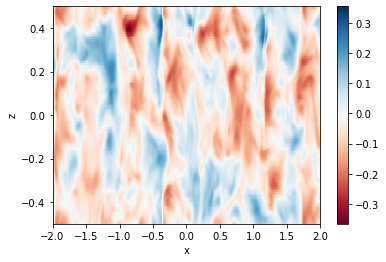

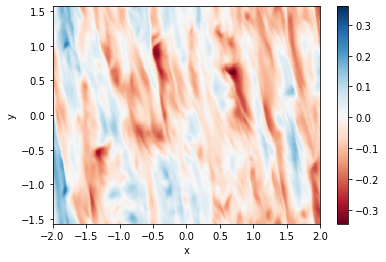

In [64]:
quantity = velx

YAVG = False

# Define a slice variable
slice_index = int(ny/2)
slice = np.s_[:,slice_index,:]

if YAVG:
    plt.pcolormesh(xcmesh[slice],zcmesh[slice],np.mean(quantity,axis=1),cmap='RdBu',shading='nearest')
else:
    plt.pcolormesh(xcmesh[slice],zcmesh[slice],quantity[slice],cmap='RdBu',shading='nearest')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('z')
plt.xlim(-2,2)

plt.show()

# Define a slice variable
slice_index = int(nz/2)
slice = np.s_[:,:,slice_index]

plt.pcolormesh(xcmesh[slice],ycmesh[slice],quantity[slice],cmap='RdBu',shading='nearest')
plt.colorbar()
plt.xlim(-2,2)
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [39]:
# Set up a test sinusoidal velocity field

ft_vx = np.fft.fftn(velx)
ft_vy = np.fft.fftn(vely) # This data already subtracts off the background shear
ft_vz = np.fft.fftn(velz)

ft_kx = np.fft.fftfreq(nx,d=(xc[1]-xc[0]))*2*np.pi
ft_ky = np.fft.fftfreq(ny,d=(yc[1]-yc[0]))*2*np.pi
ft_kz = np.fft.fftfreq(nz,d=(zc[1]-zc[0]))*2*np.pi

# Order the frequencies and fourier transforms
ft_vx = np.fft.fftshift(ft_vx)
ft_vy = np.fft.fftshift(ft_vy)
ft_vz = np.fft.fftshift(ft_vz)
ft_kx = np.fft.fftshift(ft_kx)
ft_ky = np.fft.fftshift(ft_ky)
ft_kz = np.fft.fftshift(ft_kz)

nkx = len(ft_kx)
nky = len(ft_ky)
nkz = len(ft_kz)

xaxis = np.s_[:,int(nky/2),int(nkz/2)]
yaxis = np.s_[int(nkx/2),:,int(nkz/2)]
zaxis = np.s_[int(nkx/2),int(nky/2),:]

xyplane = np.s_[:, :, int(nkz/2)]
xzplane = np.s_[:, int(nky/2), :]
yzplane = np.s_[int(nkx/2), :, :]

/home/cfairbairn/Installs/miniconda3/envs/athena/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in power
  # Remove the CWD from sys.path while we load stuff.
/home/cfairbairn/Installs/miniconda3/envs/athena/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: invalid value encountered in power
  # Remove the CWD from sys.path while we load stuff.


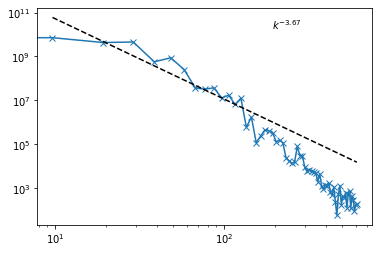

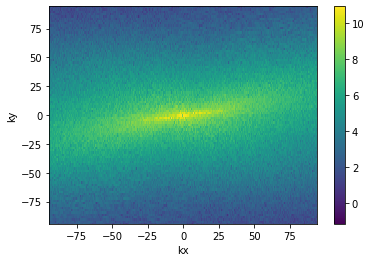

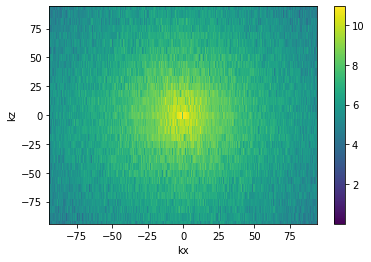

In [63]:
axslice = zaxis
ft_kaxis = ft_kz
slope=-11/3

power_spectrum = (np.abs(ft_vx)**2 + np.abs(ft_vy)**2 + np.abs(ft_vz)**2)/2

# Plot slices through the full Fourier spectrum
plt.loglog(ft_kaxis*Lx/(2*np.pi),power_spectrum[axslice],marker='x')
# Plot a Kolmogorov -5/3 slope for comparison
plt.loglog(ft_kaxis*Lx/(2*np.pi),power_spectrum[axslice][int(len(ft_kaxis)/2)+10]*pow(ft_kaxis/ft_kaxis[int(len(ft_kaxis)/2)+10],slope),linestyle='--',color='black')
# Print out the slope
plt.text(0.7,0.9,r'$k^{%1.2f}$' % slope,transform=plt.gca().transAxes)
plt.show()

# plt.pcolormesh(ft_kx*Lx/(2*np.pi),ft_ky*Ly/(2*np.pi),np.log10(power_spectrum[xyplane].T),shading='nearest')
plt.pcolormesh(ft_kx,ft_ky,np.log10(power_spectrum[xyplane].T),shading='nearest')
plt.xlabel('kx')
plt.ylabel('ky')
plt.xlim(-30*np.pi,30*np.pi)
plt.ylim(-30*np.pi,30*np.pi)
plt.colorbar()
plt.show()

# plt.pcolormesh(ft_kx,ft_kz,np.log10(power_spectrum[xzplane].T),shading='nearest')
plt.pcolormesh(ft_kx,ft_kz,np.log10(power_spectrum[xzplane].T),shading='nearest')
plt.xlabel('kx')
plt.ylabel('kz')
plt.xlim(-30*np.pi,30*np.pi)
plt.ylim(-30*np.pi,30*np.pi)
plt.colorbar()
plt.show()

Now integrate over shells in k-space to get a 1D power spectrum

In [54]:
# Now integrate over shells in k-space to get a 1D power spectrum

kmax = np.sqrt(np.max(ft_kx)**2 + np.max(ft_ky)**2 + np.max(ft_kz)**2)
nk = int(np.sqrt(nx**2 + ny**2 + nz**2)/2)
dk = 2 #kmax/nk
nk = int(kmax/dk)
kvals = (np.arange(nk)+0.5)*dk
powerspec_1D = np.zeros(nk)

for i in range(nkx):
    print('i = ', i)
    for j in range(nky):
        for k in range(nkz):
            k_mag = np.sqrt(ft_kx[i]**2 + ft_ky[j]**2 + ft_kz[k]**2)
            k_index = int(k_mag/dk)
            if k_index < nk:
                powerspec_1D[k_index] += power_spectrum[i,j,k]


i =  0
i =  1
i =  2
i =  3
i =  4
i =  5
i =  6
i =  7
i =  8
i =  9
i =  10
i =  11
i =  12
i =  13
i =  14
i =  15
i =  16
i =  17
i =  18
i =  19
i =  20
i =  21
i =  22
i =  23
i =  24
i =  25
i =  26
i =  27
i =  28
i =  29
i =  30
i =  31
i =  32
i =  33
i =  34
i =  35
i =  36
i =  37
i =  38
i =  39
i =  40
i =  41
i =  42
i =  43
i =  44
i =  45
i =  46
i =  47
i =  48
i =  49
i =  50
i =  51
i =  52
i =  53
i =  54
i =  55
i =  56
i =  57
i =  58
i =  59
i =  60
i =  61
i =  62
i =  63
i =  64
i =  65
i =  66
i =  67
i =  68
i =  69
i =  70
i =  71
i =  72
i =  73
i =  74
i =  75
i =  76
i =  77
i =  78
i =  79
i =  80
i =  81
i =  82
i =  83
i =  84
i =  85
i =  86
i =  87
i =  88
i =  89
i =  90
i =  91
i =  92
i =  93
i =  94
i =  95
i =  96
i =  97
i =  98
i =  99
i =  100
i =  101
i =  102
i =  103
i =  104
i =  105
i =  106
i =  107
i =  108
i =  109
i =  110
i =  111
i =  112
i =  113
i =  114
i =  115
i =  116
i =  117
i =  118
i =  119
i =  120
i =  121
i =  122
i =

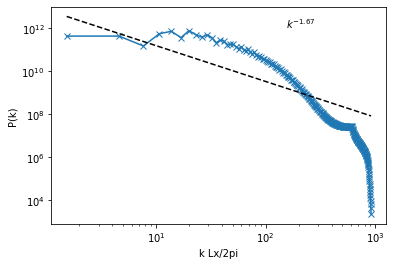

In [55]:
slope = -5/3

plt.loglog(kvals*Lx/(2*np.pi),powerspec_1D,marker='x')
# Plot a Kolmogorov -5/3 slope for comparison
plt.loglog(kvals*Lx/(2*np.pi),powerspec_1D[int(nk/4)]*pow(kvals/kvals[int(nk/4)],slope),linestyle='--',color='black')
# Print out the slope
plt.text(0.7,0.9,r'$k^{%1.2f}$' % slope,transform=plt.gca().transAxes)
plt.xlabel(r'k Lx/2pi')
plt.ylabel(r'P(k)')
plt.show()

Now test the distribution of velocities and densities.

In [42]:
# Define the bin edges
BIN_LEFT= -3.e-1
# BIN_LEFT= 0.0
BIN_RIGHT= 3.e-1
NBINS = 100
PDF = True
bin_edges = np.linspace(BIN_LEFT,BIN_RIGHT,NBINS)

# Now compute the histogram of the residuals
hist_dvx = np.histogram(velx_snaps,bins=bin_edges,weights=(dens_snaps),density=PDF)
hist_dvy = np.histogram(vely_snaps,bins=bin_edges,weights=(dens_snaps),density=PDF)
hist_dvz = np.histogram(velz_snaps,bins=bin_edges,weights=(dens_snaps),density=PDF)

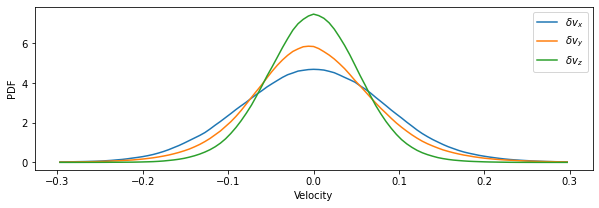

In [50]:
# now plot the distribution of the velocity perturbations

fig = plt.figure(figsize=(10, 3), constrained_layout=False)
grid = fig.add_gridspec(ncols=1, nrows=1, width_ratios = [1], height_ratios = [1.0])

ax0 = fig.add_subplot(grid[0])
bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])

ax0.plot(bin_centers,hist_dvx[0],label=r'$\delta v_x$')
ax0.plot(bin_centers,hist_dvy[0],label=r'$\delta v_y$')
ax0.plot(bin_centers,hist_dvz[0],label=r'$\delta v_z$')
ax0.set_xlabel('Velocity')
ax0.set_ylabel('PDF')
ax0.legend()
plt.show()

In [51]:
ddens_snaps = np.array(dens_snaps)-1.0

# Define the bin edges
BIN_LEFT= -3.e-1
BIN_RIGHT= 3.e-1
NBINS = 100
PDF = True
bin_edges = np.linspace(BIN_LEFT,BIN_RIGHT,NBINS)

# Now compute the histogram of the residuals
hist_ddens = np.histogram(ddens_snaps,bins=bin_edges,density=PDF)

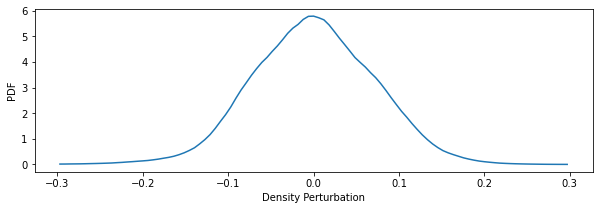

In [52]:
# now plot the distribution of the density perturbations

fig = plt.figure(figsize=(10, 3), constrained_layout=False)
grid = fig.add_gridspec(ncols=1, nrows=1, width_ratios = [1], height_ratios = [1.0])

ax0 = fig.add_subplot(grid[0])
bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1])

ax0.plot(bin_centers,hist_ddens[0])
ax0.set_xlabel('Density Perturbation')
ax0.set_ylabel('PDF')   
plt.show()

## Form of turbulence driving

### Load grid

In [3]:
import time as tmod

# Load the 3D grid
DIRECTORY='/mnt/lustre/user/cfairbairn/InclinedPert/turbtest/'
EXPID = 'turb'
SNAP=0
DATA_FILE = DIRECTORY+'{0}.out1.{1:05d}.athdf'.format(EXPID,SNAP)

QUANTITIES = ['rho','vel1','vel2','vel3']
LEVEL = None  # Sets the refinement level onto which the data is cast (0 being the coursest root refinement).

data = athena_read.athdf(DATA_FILE, quantities=QUANTITIES,level=LEVEL)

# Cell centers
xc = data['x1v']
yc = data['x2v']
zc = data['x3v']

# Cell faces
xf = data['x1f']
yf = data['x2f']
zf = data['x3f']

nx = len(xc)
ny = len(yc)
nz = len(zc)


In [4]:
xcmesh,ycmesh,zcmesh = np.meshgrid(xc,yc,zc,indexing='ij')

Lx = data['x1f'][-1] - data['x1f'][0]
Ly = data['x2f'][-1] - data['x2f'][0]
Lz = data['x3f'][-1] - data['x3f'][0]

### Test forcing wave structures

Phases =  0.43325891883453393 0.8811578386375261 0.508559059199332 0.10788829414735335 0.749058082400971 0.12728429056428936


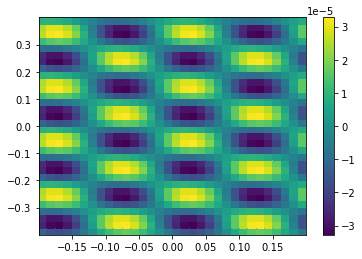

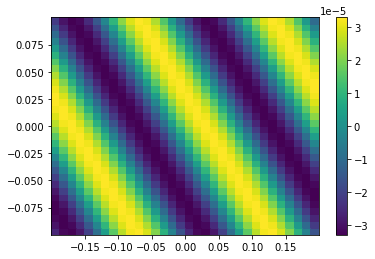

In [74]:
lam_force = 0.2
alpha_in = 4.52e-5
dtdrive = 0.001

time=0.0

method = 3

# Random number module seed with random system time
rng = np.random.default_rng(int(tmod.time()))

phi1x,phi2x,phi3x,phi1y,phi2y,phi3y,phi1z,phi2z,phi3z = rng.random(9)
print('Phases = ', phi1x,phi2x,phi1y,phi2y,phi1z,phi2z)

kx0 = (2.0*np.pi/lam_force)
ky = (2.0*np.pi/lam_force)
kz = (2.0*np.pi/lam_force)

qshear = 1.5
Omega_0 = 1.0
qomt = qshear*Omega_0*time

if (time == 0.0):
    nxt = 1.0
else:
    nxt = np.floor(1.0-qomt*ky/kx0)+1.0
    print('nxt = ', nxt)

kxt=nxt*kx0+qomt*ky
amp_force = np.sqrt(5.64*alpha_in*(Lx*Ly)*dtdrive)

# ------------------------------#
# Method 1
# ------------------------------#
if (method == 1):
    Ax = np.cos(kxt*xcmesh+phi1x)*np.cos(ky*ycmesh+phi2x)*np.cos(kz*zcmesh+phi3x)
    Ay = np.cos(kxt*xcmesh+phi1y)*np.cos(ky*ycmesh+phi2y)*np.cos(kz*zcmesh+phi3y)
    Az = np.cos(kxt*xcmesh+phi1z)*np.cos(ky*ycmesh+phi2z)*np.cos(kz*zcmesh+phi3z)

    dAxdy = -ky*np.cos(kxt*xcmesh+phi1x)*np.sin(ky*ycmesh+phi2x)*np.cos(kz*zcmesh+phi3x)
    dAxdz = -kz*np.cos(kxt*xcmesh+phi1x)*np.cos(ky*ycmesh+phi2x)*np.sin(kz*zcmesh+phi3x)
    dAydx = -kxt*np.sin(kxt*xcmesh+phi1y)*np.cos(ky*ycmesh+phi2y)*np.cos(kz*zcmesh+phi3y)
    dAydz = -kz*np.cos(kxt*xcmesh+phi1y)*np.cos(ky*ycmesh+phi2y)*np.sin(kz*zcmesh+phi3y)
    dAzdx = -kxt*np.sin(kxt*xcmesh+phi1z)*np.cos(ky*ycmesh+phi2z)*np.cos(kz*zcmesh+phi3z)
    dAzdy = -ky*np.cos(kxt*xcmesh+phi1z)*np.sin(ky*ycmesh+phi2z)*np.cos(kz*zcmesh+phi3z)

# ------------------------------#
# Method 2
# ------------------------------#
if (method == 2):

    Ax = np.cos(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1x)
    Ay = np.cos(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1y)
    Az = np.cos(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1z)

    dAxdy = -ky*np.sin(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1x)
    dAxdz = -kz*np.sin(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1x)
    dAydx = -kxt*np.sin(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1y)
    dAydz = -kz*np.sin(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1y)
    dAzdx = -kxt*np.sin(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1z)
    dAzdy = -ky*np.sin(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phi1z)

# ------------------------------#
# Method 3
# ------------------------------#
if (method == 3):

    dAxdy = -ky*np.sin(kxt*xcmesh+ky*ycmesh+phi1x)*np.cos(kz*zcmesh+phi2x)
    dAxdz = -kz*np.cos(kxt*xcmesh+ky*ycmesh+phi1x)*np.sin(kz*zcmesh+phi2x)
    dAydx = -kxt*np.sin(kxt*xcmesh+ky*ycmesh+phi1y)*np.cos(kz*zcmesh+phi2y)
    dAydz = -kz*np.cos(kxt*xcmesh+ky*ycmesh+phi1y)*np.sin(kz*zcmesh+phi2y)
    dAzdx = -kxt*np.sin(kxt*xcmesh+ky*ycmesh+phi1z)*np.cos(kz*zcmesh+phi2z)
    dAzdy = -ky*np.cos(kxt*xcmesh+ky*ycmesh+phi1z)*np.sin(kz*zcmesh+phi2z)

# ------------------------------#
# Plot quantities
# ------------------------------#
    
dv1 = (amp_force/ky)*(dAzdy - dAydz)
dv2 = (amp_force/ky)*(dAxdz - dAzdx)
dv3 = (amp_force/ky)*(dAydx - dAxdy)

quantity = dv1

# Define a slice variable
slice_index = int(ny/2)
slice = np.s_[:,slice_index,:]

plt.pcolormesh(xcmesh[slice],zcmesh[slice],quantity[slice],cmap='viridis',shading='nearest')
plt.colorbar()

plt.show()

# Define a slice variable
slice_index = int(nz/2)
slice = np.s_[:,:,slice_index]

plt.pcolormesh(xcmesh[slice],ycmesh[slice],quantity[slice],cmap='viridis',shading='nearest')
plt.colorbar()

plt.show()

### Time dependent forcing
Let us now try and implement a Laughlin Style forcing in the shearing box

In [82]:
import random

trun = 10

# Set a modal range to pick from

nxmax = 6
nymax = 6
nzmax = 2

Nmodes=10

# Seed a random number generator
random.seed(int(tmod.time()))

cs = 1.0
qshear = 1.5
Omega_0 = 1.0

t = 0.0
tstep = 0.1
active_modes = 0

nx_list = []
ny_list = []
nz_list = []
phase_list = []
t0_list = []

Phi_array = []

while (t<=trun):
    print('Time = ', t)

    # Remove modes which have lasted beyond their lifetime
    pos = 0 
    while (pos < len(t0_list)):
        t0 = t0_list[pos]
        ny = ny_list[pos]
        tlife = 10*Ly/(cs*np.abs(ny))
        if (t-t0 > tlife):
            nx_list.pop(pos)
            ny_list.pop(pos)
            nz_list.pop(pos)
            phase_list.pop(pos)
            t0_list.pop(pos)
            active_modes -= 1
            print('Removing mode ', pos)
        else:
            pos += 1

    # Now check if there are any inactive modes
    while(active_modes < Nmodes):
        # Choose parameters for active modes
        nx_list.append(random.randint(-nxmax, nxmax))
        ny = random.randint(1, nymax)
        ran = random.uniform(0.0,1.0)
        if (ran < 0.5):
            ny = -ny
        else:
            ny = ny
        ny_list.append(ny)
        nz_list.append(random.randint(-nzmax, nzmax))
        phase_list.append(random.random()*2.0*np.pi)
        t0_list.append(t)
        active_modes += 1

    Phi = 0
    for mode in range(0,Nmodes):
        nx = nx_list[mode]
        ny = ny_list[mode]
        nz = nz_list[mode]
        phase = phase_list[mode]

        kx = (2.0*np.pi/Lx)*nx
        ky = (2.0*np.pi/Ly)*ny
        kz = (2.0*np.pi/Lz)*nz

        qomt = qshear*Omega_0*(t-t0_list[mode])
        kxt=kx+qomt*ky

        tlife = 10*Ly/(cs*np.abs(ny))
        Phi += np.cos(kxt*xcmesh+ky*ycmesh+kz*zcmesh+phase)*np.sin(np.pi*(t-t0_list[mode])/tlife)
    
    Phi_array.append(Phi)
    t += tstep

Time =  0.0
Time =  0.1
Time =  0.2
Time =  0.30000000000000004
Time =  0.4
Time =  0.5
Removing mode  0
Removing mode  3
Time =  0.6
Removing mode  6
Time =  0.7
Removing mode  1
Removing mode  2
Removing mode  2
Removing mode  2
Removing mode  2
Time =  0.7999999999999999
Time =  0.8999999999999999
Removing mode  2
Time =  0.9999999999999999
Time =  1.0999999999999999
Removing mode  0
Removing mode  0
Removing mode  0
Removing mode  2
Time =  1.2
Removing mode  0
Removing mode  0
Removing mode  1
Time =  1.3
Removing mode  0
Removing mode  1
Time =  1.4000000000000001
Removing mode  0
Time =  1.5000000000000002
Removing mode  0
Time =  1.6000000000000003
Removing mode  4
Time =  1.7000000000000004
Removing mode  0
Time =  1.8000000000000005
Removing mode  1
Removing mode  2
Removing mode  3
Time =  1.9000000000000006
Removing mode  1
Time =  2.0000000000000004
Removing mode  2
Time =  2.1000000000000005
Time =  2.2000000000000006
Time =  2.3000000000000007
Removing mode  7
Time =  2.

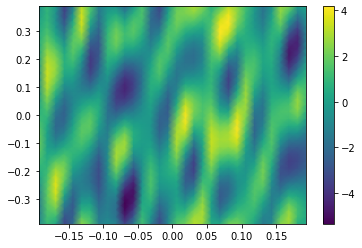

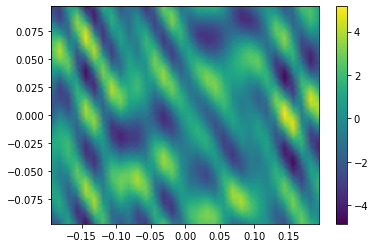

In [87]:
quantity = Phi_array[4]

# Define a slice variable
slice_index = int(ny/2)
slice = np.s_[:,slice_index,:]

plt.pcolormesh(xcmesh[slice],zcmesh[slice],quantity[slice],cmap='viridis',shading='gouraud')
plt.colorbar()

plt.show()

# Define a slice variable
slice_index = int(nz/2)
slice = np.s_[:,:,slice_index]

plt.pcolormesh(xcmesh[slice],ycmesh[slice],quantity[slice],cmap='viridis',shading='gouraud')
plt.colorbar()

plt.show()

### Simple turbulent forcing field

In [126]:
turbamp = 0.1

kx = np.pi
ky = np.pi
kz = np.pi

fx = +turbamp*np.sin(kx*xcmesh)*np.cos(ky*ycmesh)*np.cos(kz*zcmesh)
fy = -turbamp*np.cos(kx*xcmesh)*np.sin(ky*ycmesh)*np.cos(kz*zcmesh)  
fz = +turbamp*np.sin(kz*zcmesh)


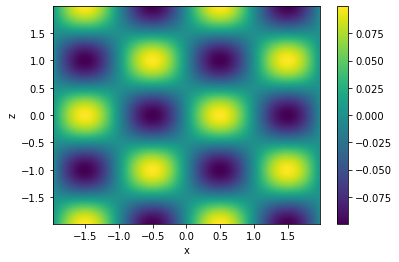

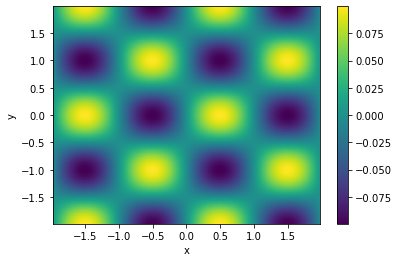

In [127]:
quantity = fx

# Define a slice variable
slice_index = int(ny/2)
slice = np.s_[:,slice_index,:]

plt.pcolormesh(xcmesh[slice],zcmesh[slice],quantity[slice],cmap='viridis',shading='gouraud')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('z')

plt.show()

# Define a slice variable
slice_index = int(nz/2)
slice = np.s_[:,:,slice_index]

plt.pcolormesh(xcmesh[slice],ycmesh[slice],quantity[slice],cmap='viridis',shading='gouraud')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')

plt.show()

### Gaussian Random Field

In [5]:
#Create the k-vector grid from the physical grid

ft_nx = np.fft.fftfreq(nx,d=(xf[1]-xf[0]))*Lx
ft_nx = np.fft.fftshift(ft_nx)

# ft_fy = np.fft.fftn(fy)
# ft_fz = np.fft.fftn(fz)

In [42]:
# form a hemisphere of wavenumbers

nxmin = -5
nxmax = 5
nymin = -5
nymax = 5
nzmin = -5
nzmax = 5

nxlist = np.arange(nxmin,nxmax+1)
nylist = np.arange(nymin,nymax+1)
nzlist = np.arange(nzmin,nzmax+1)

nxcmesh,nycmesh,nzcmesh = np.meshgrid(nxlist,nylist,nzlist,indexing='ij')

nrad = 2

# Now form a list of all modes within the hemisphere
nlist = []
for nx in nxlist:
    for ny in nylist:
        for nz in nzlist:
            nmag = np.sqrt(nx**2 + ny**2 + nz**2)
            if (nmag>nrad) or (nmag==0) or (nmag < 0) or nx < 0:
                continue
            nlist.append([nx,ny,nz])


In [76]:
namps = np.zeros((len(nxlist),len(nylist),len(nzlist)),dtype=complex)

for mode in nlist:
    nx = mode[0]
    ny = mode[1]
    nz = mode[2]

    inx = nx + abs(nxmin)
    iny = ny + abs(nymin)
    inz = nz + abs(nzmin)

    Pk = 1.0/(nx**2 + 10*ny**2 + nz**2)

    namps[inx,iny,inz] = 0
    for i in range(50):
        namps[inx,iny,inz] = Pk*np.random.normal(0, 1)*np.exp(1j*np.random.uniform(0,2.0*np.pi))/50

# Now populate based on the symmetries of the Fourier transform point symmetry is conjugate 
    
# Isolate the modes in the right half plane
for nx in nxlist:
    for ny in nylist:
        for nz in nzlist:
            if nx < 0:
                continue

            inx = nx + abs(nxmin)
            iny = ny + abs(nymin)
            inz = nz + abs(nzmin)

            # Now find the negative mode
            nnx = -nx
            nny = -ny
            nnz = -nz

            inx_neg = nnx + abs(nxmin)
            iny_neg = nny + abs(nymin)
            inz_neg = nnz + abs(nzmin)

            namps[inx_neg,iny_neg,inz_neg] = namps[inx,iny,inz]

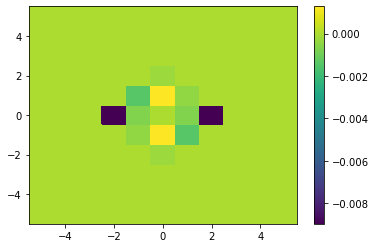

In [77]:
# plot modes which exsit as bright spots on the pcolor mesh 

zslice = int((nzmax - nzmin)/2)

plt.pcolormesh(nxcmesh[:,:,zslice],nycmesh[:,:,zslice],np.real(namps[:,:,zslice]),shading='auto')
plt.colorbar()


plt.show()


In [78]:
# Now identigy the coordinates of the modes in the ball
mode_coords = []

for nx in nxlist:
    for ny in nylist:
        for nz in nzlist:
            nmag = np.sqrt(nx**2 + ny**2 + nz**2)
            if (nmag>nrad) or (nmag==0):
                continue
            inx = nx + abs(nxmin)
            iny = ny + abs(nymin)
            inz = nz + abs(nzmin)
            mode_coords.append([inx,iny,inz])

In [79]:
# Now reconstruct the velocity field

vx_recon = np.zeros(np.shape(xcmesh))

for coord in mode_coords:
    inx = coord[0]
    iny = coord[1]
    inz = coord[2]

    nx_mode = nxlist[inx] 
    ny_mode = nylist[iny] 
    nz_mode = nzlist[inz] 

    print('nx_mode = ', nx_mode, '  ny_mode = ', ny_mode, '  nz_mode = ', nz_mode)

    kx = (2.0*np.pi/Lx)*nx_mode
    ky = (2.0*np.pi/Ly)*ny_mode
    kz = (2.0*np.pi/Lz)*nz_mode

    phase = np.random.random()*2.0*np.pi

    vx_recon += np.real(namps[inx,iny,inz]*np.exp(1j*(kx*xcmesh+ky*ycmesh+kz*zcmesh)))



nx_mode =  -2   ny_mode =  0   nz_mode =  0
nx_mode =  -1   ny_mode =  -1   nz_mode =  -1
nx_mode =  -1   ny_mode =  -1   nz_mode =  0
nx_mode =  -1   ny_mode =  -1   nz_mode =  1
nx_mode =  -1   ny_mode =  0   nz_mode =  -1
nx_mode =  -1   ny_mode =  0   nz_mode =  0
nx_mode =  -1   ny_mode =  0   nz_mode =  1
nx_mode =  -1   ny_mode =  1   nz_mode =  -1
nx_mode =  -1   ny_mode =  1   nz_mode =  0
nx_mode =  -1   ny_mode =  1   nz_mode =  1
nx_mode =  0   ny_mode =  -2   nz_mode =  0
nx_mode =  0   ny_mode =  -1   nz_mode =  -1
nx_mode =  0   ny_mode =  -1   nz_mode =  0
nx_mode =  0   ny_mode =  -1   nz_mode =  1
nx_mode =  0   ny_mode =  0   nz_mode =  -2
nx_mode =  0   ny_mode =  0   nz_mode =  -1
nx_mode =  0   ny_mode =  0   nz_mode =  1
nx_mode =  0   ny_mode =  0   nz_mode =  2
nx_mode =  0   ny_mode =  1   nz_mode =  -1
nx_mode =  0   ny_mode =  1   nz_mode =  0
nx_mode =  0   ny_mode =  1   nz_mode =  1
nx_mode =  0   ny_mode =  2   nz_mode =  0
nx_mode =  1   ny_mode =  -1  

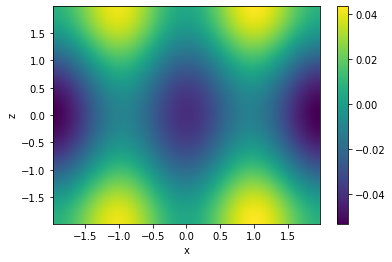

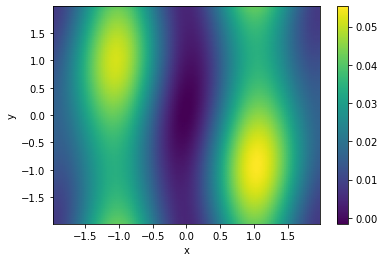

In [80]:
# Now plot the reconstructed field
quantity = vx_recon

# Define a slice variable
slice_index = int(ny/2)
slice = np.s_[:,slice_index,:]

plt.pcolormesh(xcmesh[slice],zcmesh[slice],quantity[slice],cmap='viridis',shading='gouraud')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('z')
plt.show()

# Define a slice variable
slice_index = int(nz/2)
slice = np.s_[:,:,slice_index]

plt.pcolormesh(xcmesh[slice],ycmesh[slice],quantity[slice],cmap='viridis',shading='gouraud')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Text(0, 0.5, 'ky')

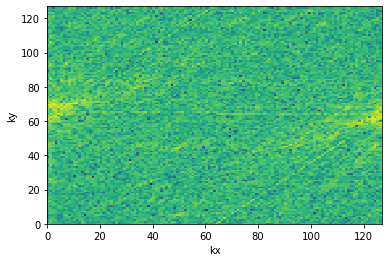

In [26]:
# Now work out the power spectrum 
ft_vx_recon = np.fft.fftn(vx_recon)
ft_vx_recon = np.fft.fftshift(ft_vx_recon)
power_spectrum_recon = (np.abs(ft_vx_recon)**2)/2
# Plot slices through the full Fourier spectrum
plt.pcolormesh(np.log10(power_spectrum_recon[:,:,zslice].T),shading='nearest')
plt.xlabel('kx')
plt.ylabel('ky')

# Testing

In [2]:
3.119e-09

3.119e-09

In [5]:
kb = 1.38e-21
massu = 1.66053906892e-27

kb/massu

831055.424006097

In [26]:
eff_gas_const = 3.119e-09
rho0 = 0.1049
T0 = 8841.630574900186
mu = 8./13.
R0 = 0.957

np.sqrt(eff_gas_const*rho0*T0/(mu*rho0))

0.006694228810330562

In [21]:
mu*(0.00667*R0)**2/8820

3.104057212628641e-09

In [28]:
np.sqrt(eff_gas_const/mu)*np.sqrt(8000)

0.006367652628716488

In [29]:
0.005**2/pow(7.12e-5,2)

4931.511172831714